In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Set device and random seeds for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)


In [2]:
# Load your datasets
df_hemo = pd.read_csv(os.path.expanduser('~/merged_hemorrhage_embeddings.csv'))
df_control = pd.read_csv(os.path.expanduser('~/merged_control_embeddings.csv'))

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to Python list.
# (Using eval here for brevity; for production consider using ast.literal_eval.)
df['embedding'] = df['embedding'].apply(eval)

# Define target columns (order is important)
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

# Extract features and labels.
# X will have shape (num_samples, 1408)
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)  # e.g., (num_samples, 1408)
print("y_train shape:", y_train.shape)


X_train shape: (12900, 1408)
y_train shape: (12900, 6)


In [3]:
class EmbeddingDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32)
        if y is not None:
            self.y = torch.tensor(y, dtype=torch.float32)
        else:
            self.y = None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        else:
            return self.X[idx]

batch_size = 32
train_dataset = EmbeddingDataset(X_train, y_train)
test_dataset = EmbeddingDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


In [4]:
class DenseModel(nn.Module):
    def __init__(self, input_dim=1408, 
                 hidden_dims=[512, 256, 128, 64],   # decreasing sizes
                 dropout=0.5, temperature=0.5):
        """
        input_dim: dimension of the flat embedding (e.g., 1408)
        hidden_dims: list of hidden layer sizes (should be decreasing)
        dropout: dropout rate for each dense block
        temperature: temperature scaling factor; T < 1 makes the sigmoid steeper.
        """
        super(DenseModel, self).__init__()
        layers_list = []
        current_dim = input_dim
        for hdim in hidden_dims:
            layers_list.append(nn.Linear(current_dim, hdim))
            layers_list.append(nn.BatchNorm1d(hdim))
            layers_list.append(nn.ReLU())
            layers_list.append(nn.Dropout(dropout))
            current_dim = hdim
        
        self.feature_extractor = nn.Sequential(*layers_list)
        self.fc_out = nn.Linear(current_dim, 6)  # final output layer for 6 target labels
        self.temperature = temperature

    def forward(self, x):
        # x shape: (batch, input_dim)
        x_feat = self.feature_extractor(x)  # (batch, current_dim)
        logits = self.fc_out(x_feat)        # (batch, 6)
        # Apply temperature scaling:
        scaled_logits = logits / self.temperature
        predictions = torch.sigmoid(scaled_logits)
        return predictions

# Instantiate the model
model = DenseModel(input_dim=1408, hidden_dims=[512, 256, 128, 64], dropout=0.5, temperature=0.5)
model = model.to(device)
print(model)


DenseModel(
  (feature_extractor): Sequential(
    (0): Linear(in_features=1408, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.5, inplace=False)
  )
  (fc_out): Linear(in_features=64, out_features=6, bias=True)
)


In [5]:
def comp_loss_fn(pred, target, weights=[2.0, 1.0, 1.0, 1.0, 1.0, 1.0]):
    loss = 0.0
    for i in range(6):
        loss += weights[i] * F.binary_cross_entropy(pred[:, i], target[:, i], reduction='mean')
    return loss / sum(weights)


In [6]:
num_epochs = 50
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 30, 40], gamma=0.1)

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # inputs shape: (batch, 1408)
        optimizer.zero_grad()
        outputs = model(inputs)  # (batch, 6)
        loss = comp_loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
    
    running_loss /= len(train_dataset)
    scheduler.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Training Loss: {running_loss:.4f}")


Epoch [1/50], Training Loss: 0.5065
Epoch [2/50], Training Loss: 0.4073
Epoch [3/50], Training Loss: 0.3922
Epoch [4/50], Training Loss: 0.3826
Epoch [5/50], Training Loss: 0.3789
Epoch [6/50], Training Loss: 0.3750
Epoch [7/50], Training Loss: 0.3720
Epoch [8/50], Training Loss: 0.3714
Epoch [9/50], Training Loss: 0.3693
Epoch [10/50], Training Loss: 0.3684
Epoch [11/50], Training Loss: 0.3669
Epoch [12/50], Training Loss: 0.3647
Epoch [13/50], Training Loss: 0.3637
Epoch [14/50], Training Loss: 0.3631
Epoch [15/50], Training Loss: 0.3639
Epoch [16/50], Training Loss: 0.3612
Epoch [17/50], Training Loss: 0.3609
Epoch [18/50], Training Loss: 0.3614
Epoch [19/50], Training Loss: 0.3609
Epoch [20/50], Training Loss: 0.3588
Epoch [21/50], Training Loss: 0.3565
Epoch [22/50], Training Loss: 0.3548
Epoch [23/50], Training Loss: 0.3547
Epoch [24/50], Training Loss: 0.3541
Epoch [25/50], Training Loss: 0.3535
Epoch [26/50], Training Loss: 0.3537
Epoch [27/50], Training Loss: 0.3536
Epoch [28/

In [7]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = comp_loss_fn(outputs, labels)
        test_loss += loss.item() * inputs.size(0)
        
test_loss /= len(test_dataset)
print(f"Test Loss: {test_loss:.4f}")

# Print sample predictions for a few samples.
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        inputs = inputs.to(device)
        outputs = model(inputs)
        outputs = outputs.cpu().numpy()
        print(f"Sample {i+1} predictions:")
        for j, col in enumerate(target_columns):
            print(f"  {col}: {outputs[0][j]:.4f}")
        if i >= 4:
            break


Test Loss: 0.3444
Sample 1 predictions:
  any: 0.5009
  epidural: 0.0134
  intraparenchymal: 0.3102
  intraventricular: 0.2136
  subarachnoid: 0.2238
  subdural: 0.2218
Sample 2 predictions:
  any: 0.8796
  epidural: 0.0428
  intraparenchymal: 0.5117
  intraventricular: 0.3809
  subarachnoid: 0.3937
  subdural: 0.3900
Sample 3 predictions:
  any: 0.9769
  epidural: 0.0362
  intraparenchymal: 0.5794
  intraventricular: 0.4197
  subarachnoid: 0.4296
  subdural: 0.4310
Sample 4 predictions:
  any: 0.5985
  epidural: 0.0187
  intraparenchymal: 0.3796
  intraventricular: 0.2704
  subarachnoid: 0.2884
  subdural: 0.2834
Sample 5 predictions:
  any: 0.5937
  epidural: 0.0198
  intraparenchymal: 0.3803
  intraventricular: 0.2742
  subarachnoid: 0.2913
  subdural: 0.2855


Temperature: 0.1, Validation Loss: 0.7703
Temperature: 0.2, Validation Loss: 0.4526
Temperature: 0.3, Validation Loss: 0.3710
Temperature: 0.4, Validation Loss: 0.3468
Temperature: 0.5, Validation Loss: 0.3444
Temperature: 0.7, Validation Loss: 0.3633
Temperature: 1.0, Validation Loss: 0.4044


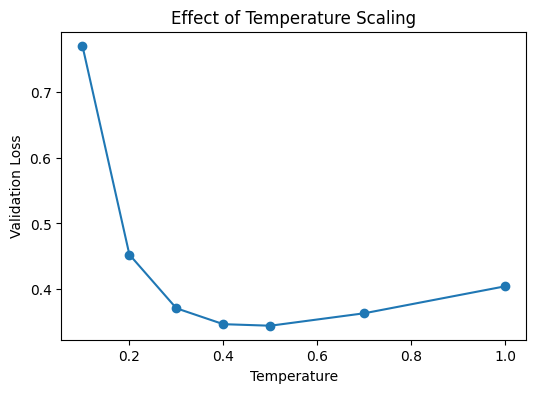

In [9]:
def evaluate_temperature(model, data_loader, temperature):
    model.eval()
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            # Get current model logits via the final fc layer
            # Here, we need to obtain logits before sigmoid.
            # We can simulate this by running through feature_extractor and fc_out:
            features = model.feature_extractor(inputs)
            logits = model.fc_out(features)
            # Apply new temperature scaling:
            scaled_logits = logits / temperature
            preds = torch.sigmoid(scaled_logits)
            loss = comp_loss_fn(preds, labels)
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)
    return total_loss / total_samples

temperature_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
losses = []
for T in temperature_values:
    current_loss = evaluate_temperature(model, test_loader, T)
    print(f"Temperature: {T}, Validation Loss: {current_loss:.4f}")
    losses.append(current_loss)

plt.figure(figsize=(6,4))
plt.plot(temperature_values, losses, marker='o')
plt.xlabel("Temperature")
plt.ylabel("Validation Loss")
plt.title("Effect of Temperature Scaling")
plt.show()
